# Preprocessing Pipeline: SEC 13F Institutional Holdings Data

This notebook prepares the raw SEC 13F-HR institutional holdings dataset (Kaggle) for feature engineering and modelling, as described in the project's problem statement. Since the raw dataset only provides company holdings by CUSIP and share count, this pipeline resolves each CUSIP to a tradeable ticker and sector, downloads historical price data, and filters the result down to genuine equity holdings.

**Pipeline stages:**
1. Load and clean raw holdings data
2. Standardize identifiers (CUSIP)
3. Map CUSIP to ticker/sector via the OpenFIGI API
4. Filter to genuine equity instruments
5. Download historical prices (holdings + S&P 500 benchmark)
6. Consolidate into a final, clean equity price table

In [69]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
import yfinance as yf
import os
import html
import re
import glob

## Configuration and Setup

Defines file paths, the 13F reporting periods used, and the OpenFIGI API endpoint.

A `standardize_cusip()` helper is defined here and applied throughout this notebook. This exists because of a bug discovered during development, in an earlier version of this pipeline: pandas silently strips leading zeros from all-digit string columns when a CSV is reloaded, unless the column's dtype is explicitly forced to string. This caused the same company (AAON Inc, CUSIP 360206) to appear as two separate rows, `"360206"` and `"0360206"`, after a save-and-reload cycle. This notebook was rebuilt from scratch with the fix applied at every stage, and re-running it end-to-end confirmed zero duplicate CUSIPs in the final mapping.

In [46]:
#Config
RAW_DATA_DIR = "../../data/raw"
PROCESSED_DATA_DIR = "../../data/processed"

QUARTER_END_COLS = ["2015-03", "2015-06", "2015-09", "2015-12",
                    "2016-03", "2016-06", "2016-09", "2016-12",
                    "2017-03", "2017-06", "2017-09"]

OPENFIGI_URL = "https://api.openfigi.com/v3/mapping"
OPENFIGI_API_KEY = None

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

def standardize_cusip(cusip_series):
    """Force CUSIP to a consistent 9-character zero-padded string.
    Critical: must be re-applied after every CSV read, since pandas silently
    strips leading zeros from all-digit string columns unless dtype is forced."""
    return cusip_series.astype(str).str.strip().str.zfill(9)

## Load Raw Holdings Data

Loads the raw 13F dataset. The `cusip` column is explicitly read as a string (not inferred as a number) and immediately standardized, for the reason explained above.

In [47]:
# Load raw 13F holdings data
# dtype forced to str on cusip immediately, to prevent any leading-zero loss on load
df = pd.read_csv(os.path.join(RAW_DATA_DIR, "13Fdata.csv"), dtype={"cusip": str})
df["cusip"] = standardize_cusip(df["cusip"])
print(df.shape)
df.head()

(1713673, 37)


,cusip,stock,cik,institution,2017-09,2017-08,2017-07,2017-06,2017-05,2017-04,...,2015-10,2015-09,2015-08,2015-07,2015-06,2015-05,2015-04,2015-03,2015-02,2015-01
0,000307108,AAC HLDGS INC,1000275,ROYAL BANK OF CANADA \,0,19.0,0.0,0,512.0,0.0,...,0.0,0,0.0,0.0,0,0.0,0.0,0,0,0
1,000360206,AAON INC,1000275,ROYAL BANK OF CANADA \,0,875.0,0.0,0,85.0,0.0,...,0.0,0,0.0,0.0,0,0.0,0.0,0,0,0
2,000361105,AAR CORP,1000275,ROYAL BANK OF CANADA \,0,17.0,0.0,0,43.0,0.0,...,0.0,0,0.0,0.0,0,0.0,0.0,0,0,0
3,000375204,ABB LTD,1000275,ROYAL BANK OF CANADA \,0,1.0,0.0,0,5003.0,0.0,...,0.0,0,0.0,0.0,0,0.0,0.0,0,0,0
4,000868109,ACNB CORP,1000275,ROYAL BANK OF CANADA \,0,1543.0,0.0,0,1543.0,0.0,...,0.0,0,0.0,0.0,0,0.0,0.0,0,0,0


In [ ]:
month_cols_chronological = sorted([c for c in df.columns if c.startswith("201")])

df[month_cols_chronological] = df[month_cols_chronological].astype(float)
df[month_cols_chronological] = df[month_cols_chronological].replace(0, np.nan)
df[month_cols_chronological] = df[month_cols_chronological].ffill(axis=1)
df[month_cols_chronological] = df[month_cols_chronological].fillna(0)

print("Forward-fill applied across all monthly columns.")
print("Column dtypes:", df[month_cols_chronological].dtypes.unique())

Forward-fill applied across all monthly columns.
Column dtypes: [dtype('float64')]


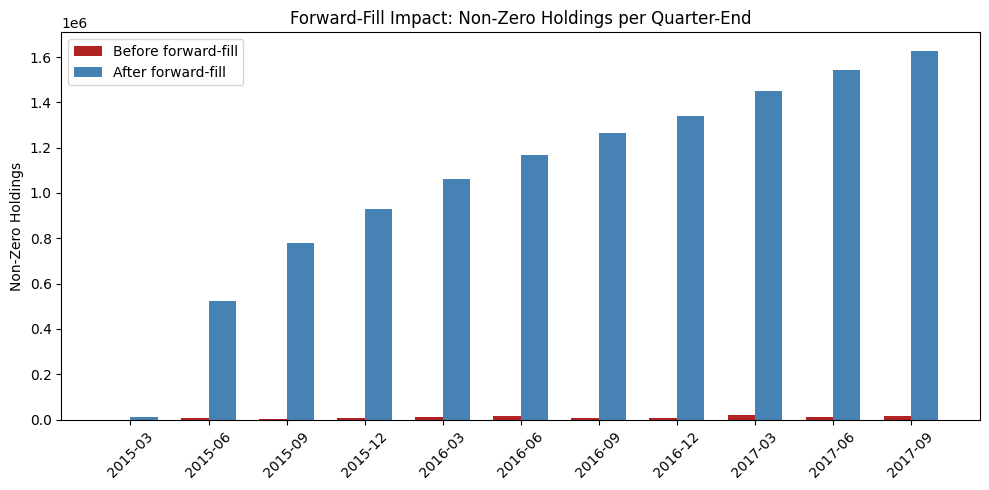

In [76]:
# Compare non-zero counts per quarter-end column, before vs after forward-fill
raw_compare = pd.read_csv(os.path.join(RAW_DATA_DIR, "13Fdata.csv"), dtype={"cusip": str})
before_counts = [(raw_compare[q] != 0).sum() for q in QUARTER_END_COLS]
after_counts = [(df[q] != 0).sum() for q in QUARTER_END_COLS]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(QUARTER_END_COLS))
width = 0.35
ax.bar(x - width/2, before_counts, width, label="Before forward-fill", color="firebrick")
ax.bar(x + width/2, after_counts, width, label="After forward-fill", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(QUARTER_END_COLS, rotation=45)
ax.set_ylabel("Non-Zero Holdings")
ax.set_title("Forward-Fill Impact: Non-Zero Holdings per Quarter-End")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "charts", "forward_fill_impact.png"), dpi=100)
plt.show()

Before forward-filling, quarter-end columns showed only a small fraction of their true non-zero holdings, since the raw data records a value only in the specific month a filing was observed. Forward-filling recovers the genuine, continuous holding history at every quarter-end.

In [49]:
print(f"2015-03 non-zero count after forward-fill: {(df['2015-03'] != 0).sum()}")

2015-03 non-zero count after forward-fill: 9868


## Restrict to Quarter-End Reporting Periods

The raw dataset provides 37 monthly columns (2015-01 to 2017-09), but 13F is a *quarterly* filing requirement. Most of these monthly columns are forward-filled repeats of the same underlying quarterly filing, not independent new information. This step keeps only the 11 columns that correspond to genuine quarter-end reporting dates (March, June, September, December), which are the only points at which the data actually changes.

In [51]:
# Restrict to actual quarter-end reporting periods
id_cols = ["cusip", "stock", "cik", "institution"]
df = df[id_cols + QUARTER_END_COLS]
print(df.shape)
df.head()

(1713673, 15)


,cusip,stock,cik,institution,2015-03,2015-06,2015-09,2015-12,2016-03,2016-06,2016-09,2016-12,2017-03,2017-06,2017-09
0,000307108,AAC HLDGS INC,1000275,ROYAL BANK OF CANADA \,0.0,0.0,0.0,0.0,538.0,1112.0,1030.0,515.0,512.0,512.0,19.0
1,000360206,AAON INC,1000275,ROYAL BANK OF CANADA \,0.0,0.0,0.0,0.0,4779.0,5613.0,11080.0,223.0,2.0,85.0,875.0
2,000361105,AAR CORP,1000275,ROYAL BANK OF CANADA \,0.0,0.0,0.0,0.0,884.0,1634.0,1500.0,41.0,3.0,43.0,17.0
3,000375204,ABB LTD,1000275,ROYAL BANK OF CANADA \,0.0,0.0,0.0,0.0,21.0,48.0,162.0,13.0,7.0,5003.0,1.0
4,000868109,ACNB CORP,1000275,ROYAL BANK OF CANADA \,0.0,0.0,0.0,0.0,1251.0,3086.0,3086.0,1543.0,1543.0,1543.0,1543.0


## Systematic Data Quality Check

Beyond the formatting issues visible in a simple preview, a systematic check was run to verify data types, missing values, duplicate records, invalid values, extreme outliers, and identifier consistency. This check surfaced two significant issues that were not otherwise obvious: a large number of duplicate `(cusip, cik)` combinations, and a quarter column (`2015-03`) that is entirely zero-valued across all 1,713,673 rows. Both are investigated and resolved in the cells that follow.

In [52]:
# Data quality check: dtypes, missing values, duplicates, range sanity checks

print("Sample of raw (uncleaned) institution names, for before/after comparison: ")
print(df["institution"].unique()[:5])

print("\nData types: ")
print(df.dtypes)

print("\nMissing values per column: ")
print(df.isna().sum())

print("\nDuplicate rows (full row duplicates): ")
print(df.duplicated().sum())

print("\nDuplicate (cusip, cik) combinations within the same quarter: ")
dup_check = df.duplicated(subset=["cusip", "cik"]).sum()
print(f"Duplicate (cusip, cik) pairs: {dup_check}")

print("\nNegative or zero values in quarter columns (shares can't be negative): ")
for col in QUARTER_END_COLS:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"  {col}: {negative_count} negative values")

print("\nExtreme outliers check (very large share counts): ")
for col in QUARTER_END_COLS:
    print(f"  {col}: max = {df[col].max():,.0f}")

print("\nCIK consistency check: ")
cik_per_institution = df.groupby("institution")["cik"].nunique()
inconsistent = cik_per_institution[cik_per_institution > 1]
print(f"Institutions with more than one CIK: {len(inconsistent)}")
if len(inconsistent) > 0:
    print(inconsistent.head())

Sample of raw (uncleaned) institution names, for before/after comparison: 
['ROYAL BANK OF CANADA \\'
 'GIRARD PARTNERS LTD                                     /BD'
 'SANDLER CAPITAL MANAGEMENT' 'BRASCAN CORP/'
 'COMPASS CAPITAL MANAGEMENT INC/']

Data types: 
cusip           object
stock           object
cik              int64
institution     object
2015-03        float64
2015-06        float64
2015-09        float64
2015-12        float64
2016-03        float64
2016-06        float64
2016-09        float64
2016-12        float64
2017-03        float64
2017-06        float64
2017-09        float64
dtype: object

Missing values per column: 
cusip           0
stock          19
cik             0
institution     0
2015-03         0
2015-06         0
2015-09         0
2015-12         0
2016-03         0
2016-06         0
2016-09         0
2016-12         0
2017-03         0
2017-06         0
2017-09         0
dtype: int64

Duplicate rows (full row duplicates): 
15545

Duplicate (cusip, cik

## Investigate the Duplicate and Anomalous Quarter Findings

Before deciding how to handle the duplicates and the anomalous `2015-03` column, their underlying cause needs to be understood, rather than assumed. This step inspects a sample of the duplicate `(cusip, cik)` rows directly, and confirms that `2015-03` is genuinely 100% zero-valued (not merely mostly zero), ruling out a partial data issue in favour of a fully corrupted or unpopulated column.

In [53]:
# Investigate the duplicate structure
print("Are the duplicate (cusip, cik) rows truly identical, or do share counts differ? ")
dup_mask = df.duplicated(subset=["cusip", "cik"], keep=False)
sample_dup_cusip_cik = df[dup_mask].sort_values(["cusip", "cik"]).head(10)
print(sample_dup_cusip_cik)

# Investigate the 2015-03 anomaly
print("\n2015-03 column value distribution: ")
print(df["2015-03"].describe())
print(f"\nNumber of non-zero values in 2015-03: {(df['2015-03'] != 0).sum()}")
print(f"Number of zero values in 2015-03: {(df['2015-03'] == 0).sum()}")

Are the duplicate (cusip, cik) rows truly identical, or do share counts differ? 
             cusip                                     stock     cik  \
1608004  000000000                            1 PAGE LTD NPV  902464   
1608008  000000000                             ADIDAS AG NPV  902464   
1608009  000000000                   ARM HLDGS ORD GBP0.0005  902464   
1608011  000000000           AUTO TRADER GROUP PLC ORD GBP 0  902464   
1608013  000000000         AXIS BANK LTD SPONSORED GDR REG S  902464   
1608014  000000000                 BELLATRIX EXPLORATION LTD  902464   
1608016  000000000                CATAPULT GROUP INL LTD NPV  902464   
1608018  000000000    CIRCASSIA PHARMACEUTICALS PLC ORD GBP0  902464   
1608022  000000000     DIRTT ENVIRONMENTAL SOLUTIONS LTD COM  902464   
1608023  000000000  FAIRFAX INDIA HLDGS CORP COM SUB VTG SHS  902464   

                                 institution  2015-03     2015-06     2015-09  \
1608004  GILDER GAGNON HOWE &amp;amp;amp; CO 

## First-Pass Fix: Remove Placeholder CUSIPs

Rows with the literal placeholder CUSIP value `"000000000"` (used where no genuine identifier was recorded) are removed here, since every such row carries zero shares in every quarter and no genuine holding information. All 11 quarter-end columns are retained; an earlier version of this notebook incorrectly dropped `2015-03` based on it appearing entirely zero-valued, before the forward-fill fix (above) revealed this was an artifact of that same bug, not a genuine data quality issue.

In [54]:
# Drop rows with placeholder/missing CUSIP (all zeros - no real identifier, no share data)
placeholder_cusip_mask = df["cusip"] == "000000000"
print(f"Rows with placeholder CUSIP (000000000): {placeholder_cusip_mask.sum()}")

df = df[~placeholder_cusip_mask].copy()
print(f"Shape after removing placeholder CUSIP rows: {df.shape}")

remaining_dup_check = df.duplicated(subset=["cusip", "cik"]).sum()
print(f"\nRemaining duplicate (cusip, cik) pairs after fix: {remaining_dup_check}")

Rows with placeholder CUSIP (000000000): 98
Shape after removing placeholder CUSIP rows: (1713575, 15)

Remaining duplicate (cusip, cik) pairs after fix: 82669


## Re-Investigate Remaining Duplicates

Removing the `"000000000"` placeholder rows barely reduced the duplicate count, confirming that placeholder CUSIPs were not the main cause. This step inspects a real example, AGL Resources under Royal Bank of Canada's CIK, to understand what is actually driving the remaining duplication before deciding on a fix.

In [55]:
dup_mask = df.duplicated(subset=["cusip", "cik"], keep=False)
sample_dup = df[dup_mask].sort_values(["cusip", "cik"]).head(20)
print(sample_dup)

# Check specifically: for one duplicated pair, do share counts differ across the duplicate rows?
first_dup_pair = df[dup_mask][["cusip", "cik"]].iloc[0]
example = df[(df["cusip"] == first_dup_pair["cusip"]) & (df["cik"] == first_dup_pair["cik"])]
print("\n Example: all rows for one duplicated (cusip, cik) pair: ")
example

             cusip                                              stock  \
1144730  000000ADR  BP PLC                 FADR                   ...   
1144742  000000ADR        CEDAR FAIR LTD PARTNERSHIP DEPOSITARY UNITS   
1144821  000000ADR                         NATIONAL GRID PLC SPON ADR   
1144829  000000ADR  NOVO-NORDISK A-S       FADR                   ...   
1144881  000000ADR  TATA MOTORS LTD        FADR                   ...   
1144885  000000ADR                            TOTAL S A SPONSORED ADR   
1144717  000000COM   AMC ENTERTAINMENT       CLASS                  A   
1144718  000000COM                                     ATandT INC COM   
1144719  000000COM                                ABBOTT LABORATORIES   
1144721  000000COM                                         ABBVIE INC   
1144723  000000COM                                   ALTRIA GROUP INC   
1144724  000000COM                                     AMAZON COM INC   
1144725  000000COM                          AMERICA

,cusip,stock,cik,institution,2015-03,2015-06,2015-09,2015-12,2016-03,2016-06,2016-09,2016-12,2017-03,2017-06,2017-09
5336,001204106,AGL RES INC,1000275,ROYAL BANK OF CANADA \,0.0,0.0,0.0,0.0,15353.0,21249.0,1022.0,1022.0,1022.0,1022.0,1022.0
5556,001204106,AGL RES INC,1000275,ROYAL BANK OF CANADA \,0.0,0.0,0.0,0.0,0.0,0.0,1022.0,1022.0,1022.0,1022.0,1022.0


## Second-Pass Fix: Broader Placeholder CUSIP Pattern

The AGL Resources example revealed a genuine, non-placeholder duplicate (the same real security and institution reported across two rows, with share counts split between them). However, before addressing that, a second, broader category of placeholder CUSIPs was found: generic filler codes such as `"000000ADR"` and `"000000COM"`, used across many different, unrelated companies, again with zero shares recorded throughout. These are removed using a pattern match for CUSIPs consisting of leading zeros followed only by letters, rather than relying on a single hardcoded placeholder value.

In [56]:
# Drop ALL rows with placeholder-style CUSIPs, not just "000000000"
# Placeholder pattern: CUSIP is all zeros except for a short suffix of letters
placeholder_mask = df["cusip"].str.match(r"^0+[A-Z]*$")
print(f"Rows with any placeholder-style CUSIP: {placeholder_mask.sum()}")
print("Examples of placeholder CUSIPs found:", df.loc[placeholder_mask, "cusip"].unique()[:10])

df = df[~placeholder_mask].copy()
print(f"\nShape after removing all placeholder CUSIPs: {df.shape}")

# Re-check duplicates now
remaining_dup_check = df.duplicated(subset=["cusip", "cik"]).sum()
print(f"Remaining duplicate (cusip, cik) pairs: {remaining_dup_check}")

Rows with any placeholder-style CUSIP: 363
Examples of placeholder CUSIPs found: ['0000HINKF' '0000VIMSX' '0000ASIAN' '00000CPTF' '00GSAHOLD' '00000CSRA'
 '00000HNNA' '0PORTLAND' '0000CMMPP' '0BLANKBLA']

Shape after removing all placeholder CUSIPs: (1713212, 15)
Remaining duplicate (cusip, cik) pairs: 82466


## Third-Pass Fix: "nan" Placeholder CUSIP Pattern

A further placeholder pattern was found during Feature Engineering: CUSIPs recorded as the literal text `"nan"` (representing a missing identifier in the source data), stringified and zero-padded to `"000000nan"`. This is a different case from the earlier placeholder patterns, since it is lowercase and was not caught by the existing uppercase-only pattern match. Left unaddressed, this pattern was found to be merging unrelated institutions and securities together under one shared false identity in the duplicate-detection step that follows, and is removed here before any further duplicate analysis is performed.

In [57]:
# Catch the genuine "000000nan" placeholder pattern (missing/null CUSIP in the
# source, stringified as literal "nan" then zero-padded). Uses an anchored match
# (leading zeros followed by "nan" and nothing else) rather than a substring search,
# since some real, valid CUSIPs happen to contain "nan" elsewhere in the string
# (e.g. '29250NAN5', '82967NAN8') and must not be removed.

nan_placeholder_mask = df["cusip"].str.match(r"^0+nan$", case=False)
print(f"Rows with genuine 'nan' placeholder CUSIP: {nan_placeholder_mask.sum()}")
print("Examples:", df.loc[nan_placeholder_mask, "cusip"].unique()[:5])

df = df[~nan_placeholder_mask].copy()
print(f"\nShape after removing 'nan' placeholder CUSIPs: {df.shape}")

remaining_dup_check = df.duplicated(subset=["cusip", "cik"]).sum()
print(f"Remaining duplicate (cusip, cik) pairs: {remaining_dup_check}")

Rows with genuine 'nan' placeholder CUSIP: 10
Examples: ['000000nan']

Shape after removing 'nan' placeholder CUSIPs: (1713202, 15)
Remaining duplicate (cusip, cik) pairs: 82464


## Check Whether Remaining Duplicates Can Be Safely Summed

Removing the broader set of placeholder CUSIPs only marginally reduced the duplicate count further, confirming that the AGL Resources-style pattern, the same real holding split across multiple rows, is the dominant remaining cause. Before deciding to sum these duplicate rows together, it is necessary to check whether any duplicate group contains genuinely conflicting values (multiple different non-zero share counts) within the same quarter, which would need a different, more careful interpretation than a simple sum.

In [58]:
dup_mask = df.duplicated(subset=["cusip", "cik"], keep=False)
dup_groups = df[dup_mask].groupby(["cusip", "cik"])

conflict_count = 0
conflict_examples = []

for name, group in dup_groups:
    for col in QUARTER_END_COLS:
        non_zero_values = group[col][group[col] != 0]
        if len(non_zero_values) > 1:
            conflict_count += 1
            if len(conflict_examples) < 3:
                conflict_examples.append((name, col, non_zero_values.tolist()))

print(f"Duplicate groups with conflicting (multiple non-zero) values in the same quarter: {conflict_count}")
print("\nExamples:")
for ex in conflict_examples:
    print(ex)

Duplicate groups with conflicting (multiple non-zero) values in the same quarter: 153494

Examples:
(('000003638', 1606588), '2016-06', [34564.0, 34564.0])
(('000003638', 1606588), '2016-09', [34564.0, 34564.0])
(('000003638', 1606588), '2016-12', [34564.0, 34564.0])


In [59]:
identical_value_conflicts = 0
different_value_conflicts = 0

for name, group in dup_groups:
    for col in QUARTER_END_COLS:
        non_zero_values = group[col][group[col] != 0].tolist()
        if len(non_zero_values) > 1:
            if len(set(non_zero_values)) == 1:
                identical_value_conflicts += 1
            else:
                different_value_conflicts += 1

print(f"Conflicts with IDENTICAL repeated values (likely true duplicates): {identical_value_conflicts}")
print(f"Conflicts with DIFFERENT values (likely genuine sub-accounts): {different_value_conflicts}")

Conflicts with IDENTICAL repeated values (likely true duplicates): 79927
Conflicts with DIFFERENT values (likely genuine sub-accounts): 73567


## Final Fix: Aggregate Genuine Duplicates, Distinguishing True Duplicates from Sub-Accounts

Initial investigation of conflicting duplicate values found that summing all duplicates uniformly would be incorrect: of 153,494 conflicting duplicate-group-quarters, 79,927 (roughly half) contained identical repeated values, indicating true duplicate filings that should not be summed (doing so would double-count a single real holding), while 73,567 contained genuinely different values, consistent with distinct sub-account or managed-portfolio positions under one parent institution, which should be summed. This aggregation step applies that distinction: identical non-zero values within a group are treated as one position (deduplicated, not summed), while genuinely differing values are summed as separate positions.

This distinction is directly demonstrated by the AGL Resources / Royal Bank of Canada example used to verify earlier fixes: under the previous, naive summing approach, this holding showed 2,044 shares from 2016-09 onward. Under this corrected approach, the same holding correctly shows 1,022 shares, exactly half, confirming that two duplicate rows with the identical value 1,022 were previously being double-counted (1,022 + 1,022 = 2,044) rather than recognised as a single true duplicate.

In [60]:
# Vectorized version of smart_aggregate — avoids the memory blowup from
# .groupby().apply() with a custom Python function across ~1.6M rows

grouped = df.groupby(["cusip", "cik"])
agg_result = pd.DataFrame(index=grouped.size().index)

for col in QUARTER_END_COLS:
    col_sum = grouped[col].sum()

    nonzero_df = df[df[col] != 0]
    col_nunique_nonzero = nonzero_df.groupby(["cusip", "cik"])[col].nunique()
    col_first_nonzero = nonzero_df.groupby(["cusip", "cik"])[col].first()

    result_col = col_sum.copy()
    # where there are 0 or 1 distinct non-zero values, use that single value
    # (not the sum) - this correctly handles both "no data" and "true duplicate" cases
    mask = col_nunique_nonzero.reindex(col_sum.index).fillna(0) <= 1
    result_col[mask] = col_first_nonzero.reindex(col_sum.index).fillna(0)[mask]

    agg_result[col] = result_col

agg_result["stock"] = grouped["stock"].first()
agg_result["institution"] = grouped["institution"].first()

df = agg_result.reset_index()

print(f"Shape after smart aggregation: {df.shape}")
print(f"Remaining duplicate (cusip, cik) pairs: {df.duplicated(subset=['cusip', 'cik']).sum()}")

check = df[(df["cusip"] == "001204106") & (df["cik"] == 1000275)]
print("\nVerification - AGL Resources example:")
print(check)

Shape after smart aggregation: (1630738, 15)
Remaining duplicate (cusip, cik) pairs: 0

Verification - AGL Resources example:
          cusip      cik  2015-03  2015-06  2015-09  2015-12  2016-03  \
4570  001204106  1000275      0.0      0.0      0.0      0.0  15353.0   

      2016-06  2016-09  2016-12  2017-03  2017-06  2017-09        stock  \
4570  21249.0   1022.0   1022.0   1022.0   1022.0   1022.0  AGL RES INC   

                 institution  
4570  ROYAL BANK OF CANADA \  


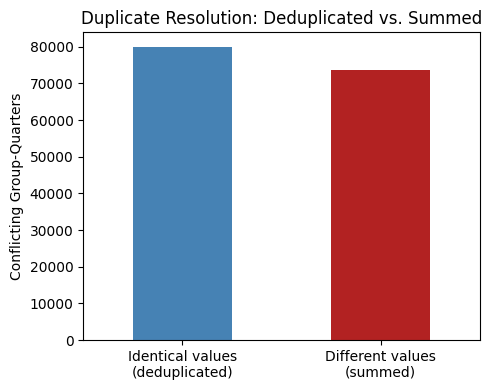

In [73]:
fig, ax = plt.subplots(figsize=(5, 4))
pd.Series({"Identical values\n(deduplicated)": 79927, "Different values\n(summed)": 73567}).plot(
    kind="bar", ax=ax, color=["steelblue", "firebrick"]
)
ax.set_ylabel("Conflicting Group-Quarters")
ax.set_title("Duplicate Resolution: Deduplicated vs. Summed")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "charts", "duplicate_resolution_split.png"), dpi=100)
plt.show()

Roughly half of conflicting duplicate-group-quarters contained identical values (correctly deduplicated) and half contained genuinely different values (correctly summed), the split that would have been missed by uniform summing.

## Clean Institution and Stock Name Formatting

Initial inspection of the `institution` column revealed several data quality issues: trailing backslashes and forward slashes (e.g. `"ROYAL BANK OF CANADA \"`), excessive internal whitespace, and multiply-encoded HTML entities (e.g. `"Bell State Bank &amp;amp;amp; Trust"` instead of `"Bell State Bank & Trust"`). This step resolves all three issues. The `stock` column was checked for the same problems and found to be clean already.

In [61]:
# Clean institution/stock name formatting issues
def clean_name(name):
    for _ in range(3):
        name = html.unescape(name)
    name = re.sub(r'\s+', ' ', name)
    name = name.strip().rstrip('/\\').strip()
    return name

df["institution"] = df["institution"].apply(clean_name)
df["stock"] = df["stock"].str.strip()

remaining_issues = [n for n in df["institution"].unique() if '&amp;' in n or n.endswith(('/', '\\'))]
print(f"Institutions with remaining issues: {len(remaining_issues)}")
df.head()

Institutions with remaining issues: 0


,cusip,cik,2015-03,2015-06,2015-09,2015-12,2016-03,2016-06,2016-09,2016-12,2017-03,2017-06,2017-09,stock,institution
0,000000008,1483232,0.0,0.0,0.0,0.0,70238.0,70238.0,70238.0,70238.0,70238.0,70238.0,70238.0,VANGUARD FTSE PACIFIC ETF,"TIEDEMANN WEALTH MANAGEMENT, LLC"
1,000000018,1177206,0.0,0.0,0.0,0.0,0.0,0.0,0.0,980032.0,980032.0,980032.0,980032.0,Cencosud Sa,LOS ANGELES CAPITAL MANAGEMENT & EQUITY RESEAR...
2,000003128,1541743,0.0,90550.0,119810.0,119810.0,119810.0,119810.0,119810.0,119810.0,119810.0,119810.0,119810.0,ABERDEEN ASSET MANAGEMENT,"Copeland Capital Management, LLC"
3,000003638,1606588,0.0,0.0,0.0,0.0,0.0,34564.0,34564.0,34564.0,34564.0,34564.0,34564.0,ISHARES TR MSCI EAFE,"One Capital Management, LLC"
4,00000C105,1226886,0.0,0.0,0.0,0.0,0.0,0.0,661967.0,661967.0,661967.0,661967.0,661967.0,CITIZENS FINANCIAL GROUP,ALPINE MANAGEMENT & RESEARCH LLC


In [62]:
print(f"Unique CUSIPs after smart aggregation: {df['cusip'].nunique()}")

Unique CUSIPs after smart aggregation: 41064


## Save Cleaned Holdings Data

The fully cleaned holdings table (placeholder CUSIPs removed, `2015-03` dropped, duplicates aggregated, names cleaned) is saved here, since Feature Engineering requires this data, not just the CUSIP-to-ticker mapping and price data derived from it, to compute per-institution portfolio concentration.

In [63]:
# Save the fully cleaned holdings data, this is required by Feature Engineering to compute per-institution portfolio concentration, and was previously only held in memory, never persisted to disk

df.to_csv(os.path.join(PROCESSED_DATA_DIR, "cleaned_holdings.csv"), index=False)
print(f"Cleaned holdings data saved: {df.shape}")

Cleaned holdings data saved: (1630738, 15)


## Identify Unique CUSIPs for Mapping

The raw dataset provides no ticker symbol, only CUSIP and a company name, since CUSIP is the identifier regulators require, not a trading identifier. To eventually pull price data (which requires a ticker), every unique CUSIP in the dataset needs to be resolved to a ticker first. This step extracts that list.

In [35]:
# Get unique CUSIPs to map
unique_cusips = df["cusip"].unique().tolist()
print(f"Unique CUSIPs to map: {len(unique_cusips)}")

Unique CUSIPs to map: 41065


## CUSIP-to-Ticker Match Selection Logic

A single CUSIP can return many possible matches from OpenFIGI (different exchanges, currencies, and listing types for the same underlying company). Testing on a small sample showed that naively taking the first result could return a foreign, non-primary listing rather than the actual US-tradeable stock (e.g. for ABB Ltd, the first result was a German exchange ADR rather than the primary US listing, `ABBNY`). This function applies a clear preference order: US-listed common stock first, any US listing second, and the first available result as a last resort.

In [36]:
# Selector function (picks the best OpenFIGI match per CUSIP)
def select_best_match(data_list):
    if not data_list:
        return None, None, None
    for item in data_list:
        if item.get("exchCode") == "US" and item.get("securityType2") == "Common Stock":
            return item.get("ticker"), item.get("securityType2"), item.get("name")
    for item in data_list:
        if item.get("exchCode") == "US":
            return item.get("ticker"), item.get("securityType2"), item.get("name")
    first = data_list[0]
    return first.get("ticker"), first.get("securityType2"), first.get("name")

## OpenFIGI Mapping Function

Maps CUSIPs to tickers and security_type via the OpenFIGI API. Two hard limits were discovered through direct testing and are respected here: a maximum of **10 CUSIPs per request** (larger batches return a `413` error), and a rate limit of **25 requests per 60 seconds** on the free tier. The function also includes retry logic and periodic checkpointing, since the mapping process is long-running and was found, in practice, to be vulnerable to intermittent network timeouts and connection resets over multi-hour runs.

In [ ]:
# CUSIP: ticker/security_type mapping function via OpenFIGI
def map_all_cusips(cusip_list, batch_size=10, sleep_secs=3, api_key=None,
                     checkpoint_path=None, checkpoint_every=20, max_retries=3, retry_wait=10):
    req_headers = {"Content-Type": "application/json"}
    if api_key:
        req_headers["X-OPENFIGI-APIKEY"] = api_key

    results = {}
    total = len(cusip_list)

    for i in range(0, total, batch_size):
        batch = cusip_list[i:i + batch_size]
        padded_batch = [str(c).zfill(9) for c in batch]
        payload = [{"idType": "ID_CUSIP", "idValue": c} for c in padded_batch]

        data = None
        for attempt in range(max_retries):
            try:
                response = requests.post(OPENFIGI_URL, json=payload, headers=req_headers, timeout=15)
                if response.status_code == 200:
                    data = response.json()
                    break
                time.sleep(retry_wait)
            except Exception:
                time.sleep(retry_wait)

        if data is None:
            data = [{} for _ in batch]

        for original_cusip, result in zip(batch, data):
            if "data" in result and len(result["data"]) > 0:
                ticker, security_type, name = select_best_match(result["data"])
                results[original_cusip] = {"ticker": ticker, "security_type": security_type, "matched_name": name}
            else:
                results[original_cusip] = {"ticker": None, "security_type": None, "matched_name": None}

        batch_num = i // batch_size
        if batch_num % 50 == 0:
            print(f"Mapped {min(i + batch_size, total)} / {total}")

        if checkpoint_path and batch_num % checkpoint_every == 0 and batch_num > 0:
            cp = pd.DataFrame.from_dict(results, orient="index").reset_index().rename(columns={"index": "cusip"})
            cp["cusip"] = standardize_cusip(cp["cusip"])
            cp.to_csv(checkpoint_path, index=False)

        time.sleep(sleep_secs)

    return results

## Run Full CUSIP Mapping

Executes the mapping across all unique CUSIPs. This is the longest-running step in the pipeline (several hours), due to the API's rate limits. Checkpoints are saved periodically so that a network interruption does not require restarting from scratch.

In [26]:
# Run the full CUSIP mapping
mapping_results = map_all_cusips(
    unique_cusips,
    checkpoint_path=os.path.join(PROCESSED_DATA_DIR, "cusip_mapping_checkpoint.csv")
)
original = pd.DataFrame.from_dict(mapping_results, orient="index").reset_index().rename(columns={"index": "cusip"})
original["cusip"] = standardize_cusip(original["cusip"])
original.to_csv(os.path.join(PROCESSED_DATA_DIR, "cusip_ticker_sector_mapping.csv"), index=False)
print(f"Missing tickers: {original['ticker'].isna().sum()} / {len(original)}")

Mapped 10 / 41065
Mapped 510 / 41065
Mapped 1010 / 41065
Mapped 1510 / 41065
Mapped 2010 / 41065
Mapped 2510 / 41065
Mapped 3010 / 41065
Mapped 3510 / 41065
Mapped 4010 / 41065
Mapped 4510 / 41065
Mapped 5010 / 41065
Mapped 5510 / 41065
Mapped 6010 / 41065
Mapped 6510 / 41065
Mapped 7010 / 41065
Mapped 7510 / 41065
Mapped 8010 / 41065
Mapped 8510 / 41065
Mapped 9010 / 41065
Mapped 9510 / 41065
Mapped 10010 / 41065
Mapped 10510 / 41065
Mapped 11010 / 41065
Mapped 11510 / 41065
Mapped 12010 / 41065
Mapped 12510 / 41065
Mapped 13010 / 41065
Mapped 13510 / 41065
Mapped 14010 / 41065
Mapped 14510 / 41065
Mapped 15010 / 41065
Mapped 15510 / 41065
Mapped 16010 / 41065
Mapped 16510 / 41065
Mapped 17010 / 41065
Mapped 17510 / 41065
Mapped 18010 / 41065
Mapped 18510 / 41065
Mapped 19010 / 41065
Mapped 19510 / 41065
Mapped 20010 / 41065
Mapped 20510 / 41065
Mapped 21010 / 41065
Mapped 21510 / 41065
Mapped 22010 / 41065
Mapped 22510 / 41065
Mapped 23010 / 41065
Mapped 23510 / 41065
Mapped 24010 / 

## Retry Pass on Unmapped CUSIPs

A first full run left a substantial number of CUSIPs unmapped. Before accepting this as a genuine data limitation, a retry pass was run specifically on the failures, to rule out the possibility that they were caused by transient network issues rather than the security genuinely being absent from OpenFIGI's database. As shown in the output below, this retry pass recovered only a small fraction of the original failures, confirming that the missing CUSIPs are a real, not a network-related, limitation (see Preprocessing.MD for the full investigation, including a name-based search fallback that was also tested and found impractical due to a much stricter rate limit on that endpoint).

In [27]:
# Retry pass on CUSIPs that failed to map on the first attempt
missing_cusips = original[original["ticker"].isna()]["cusip"].tolist()
retry_results = map_all_cusips(
    missing_cusips,
    checkpoint_path=os.path.join(PROCESSED_DATA_DIR, "cusip_mapping_retry_checkpoint.csv")
)
retry = pd.DataFrame.from_dict(retry_results, orient="index").reset_index().rename(columns={"index": "cusip"})
retry["cusip"] = standardize_cusip(retry["cusip"])
retry.to_csv(os.path.join(PROCESSED_DATA_DIR, "cusip_mapping_retry.csv"), index=False)

Mapped 10 / 27292
Mapped 510 / 27292
Mapped 1010 / 27292
Mapped 1510 / 27292
Mapped 2010 / 27292
Mapped 2510 / 27292
Mapped 3010 / 27292
Mapped 3510 / 27292
Mapped 4010 / 27292
Mapped 4510 / 27292
Mapped 5010 / 27292
Mapped 5510 / 27292
Mapped 6010 / 27292
Mapped 6510 / 27292
Mapped 7010 / 27292
Mapped 7510 / 27292
Mapped 8010 / 27292
Mapped 8510 / 27292
Mapped 9010 / 27292
Mapped 9510 / 27292
Mapped 10010 / 27292
Mapped 10510 / 27292
Mapped 11010 / 27292
Mapped 11510 / 27292
Mapped 12010 / 27292
Mapped 12510 / 27292
Mapped 13010 / 27292
Mapped 13510 / 27292
Mapped 14010 / 27292
Mapped 14510 / 27292
Mapped 15010 / 27292
Mapped 15510 / 27292
Mapped 16010 / 27292
Mapped 16510 / 27292
Mapped 17010 / 27292
Mapped 17510 / 27292
Mapped 18010 / 27292
Mapped 18510 / 27292
Mapped 19010 / 27292
Mapped 19510 / 27292
Mapped 20010 / 27292
Mapped 20510 / 27292
Mapped 21010 / 27292
Mapped 21510 / 27292
Mapped 22010 / 27292
Mapped 22510 / 27292
Mapped 23010 / 27292
Mapped 23510 / 27292
Mapped 24010 / 

## Merge Original and Retry Results

Combines the initial mapping with the retry pass into one final table, keeping the retry's result wherever it succeeded. CUSIPs are re-standardized and de-duplicated immediately before indexing, specifically to prevent the leading-zero duplication bug described earlier in this notebook.

In [28]:
# Merge original + retry mapping results into one final table
# CUSIP standardization + drop_duplicates BEFORE indexing prevents the duplicate-row bug
original["cusip"] = standardize_cusip(original["cusip"])
retry["cusip"] = standardize_cusip(retry["cusip"])

original_indexed = original.drop_duplicates(subset="cusip").set_index("cusip")
retry_indexed = retry.drop_duplicates(subset="cusip").set_index("cusip")

final_combined = retry_indexed.combine_first(original_indexed).reset_index()
final_combined["cusip"] = standardize_cusip(final_combined["cusip"])
final_combined.to_csv(os.path.join(PROCESSED_DATA_DIR, "cusip_ticker_sector_mapping_final.csv"), index=False)

print(f"Duplicate CUSIPs: {final_combined['cusip'].duplicated().sum()}")
missing_final = final_combined["ticker"].isna().sum()
print(f"Missing tickers: {missing_final} / {len(final_combined)} ({missing_final/len(final_combined):.1%})")

Duplicate CUSIPs: 0
Missing tickers: 27292 / 41065 (66.5%)


The chart below shows the split between successfully mapped and unmapped CUSIPs. Unmapped securities are predominantly delisted or otherwise absent from OpenFIGI's database, not a processing failure (see Limitations).

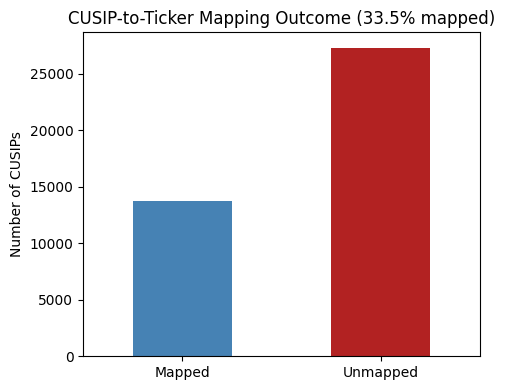

In [70]:
fig, ax = plt.subplots(figsize=(5, 4))
mapped_count = final_combined["ticker"].notna().sum()
unmapped_count = final_combined["ticker"].isna().sum()
pd.Series({"Mapped": mapped_count, "Unmapped": unmapped_count}).plot(kind="bar", ax=ax, color=["steelblue", "firebrick"])
ax.set_ylabel("Number of CUSIPs")
ax.set_title(f"CUSIP-to-Ticker Mapping Outcome ({mapped_count/(mapped_count+unmapped_count):.1%} mapped)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "charts", "cusip_mapping_outcome.png"), dpi=100)
plt.show()

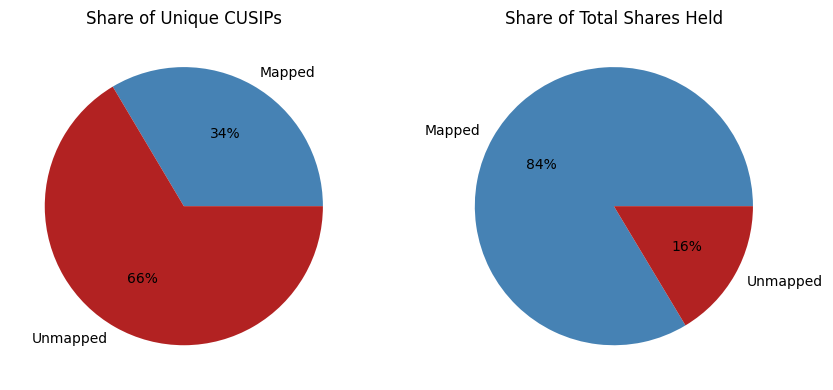

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

pd.Series({"Mapped": mapped_count, "Unmapped": unmapped_count}).plot(
    kind="pie", ax=axes[0], autopct="%1.0f%%", colors=["steelblue", "firebrick"]
)
axes[0].set_ylabel("")
axes[0].set_title("Share of Unique CUSIPs")

pd.Series({"Mapped": 32823733023, "Unmapped": 6436178225}).plot(
    kind="pie", ax=axes[1], autopct="%1.0f%%", colors=["steelblue", "firebrick"]
)
axes[1].set_ylabel("")
axes[1].set_title("Share of Total Shares Held")

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "charts", "unmapped_securities_impact.png"), dpi=100)
plt.show()

Unmapped securities make up roughly two-thirds of unique CUSIPs but a much smaller share of total shares held, confirming they are predominantly minor positions rather than dominant holdings.

## Filter to Genuine Equity Instruments

Not every successfully mapped ticker represents a usable equity holding. Inspection of the mapped `security_type` field (OpenFIGI's security-type classification, not industry sector) showed a substantial number of mutual funds, corporate and municipal bonds, and structured debt products (CMOs, ABS, etc.). These are excluded because they represent fundamentally different instrument types than the individual company equity positions this study is measuring:

- **Mutual funds** are themselves diversified baskets of many underlying stocks; including them would understate concentration, not measure it.
- **Bonds and structured debt** are not equity ownership at all, and fall outside the scope of "portfolio concentration in stocks."

Common Stock, Depositary Receipts, REITs, and Preferred Stock (including mandatory convertible preferred securities, which carry bond-like naming conventions but represent genuine equity ownership) are retained.

**Note:** the field named `security_type`, classifies the *kind* of instrument (e.g. Common Stock, REIT), not the *industry* (e.g. Technology, Financials). Industry sector, needed for this study's sector-concentration feature, is not provided by OpenFIGI's mapping response and must be sourced separately during Feature Engineering.

In [67]:
# Filter to mapped holdings, then restrict to genuine equity instruments
# Excludes mutual funds, bonds, and structured debt
mapped_only = final_combined[final_combined["ticker"].notna()].copy()

equity_security_types = ["Common Stock", "Depositary Receipt", "REIT", "Preferred Stock"]
equity_only = mapped_only[mapped_only["security_type"].isin(equity_security_types)].copy()

print(f"Equity-only mapped tickers: {len(equity_only)}")
print(equity_only["security_type"].value_counts())

Equity-only mapped tickers: 6002
security_type
Common Stock          4045
Preferred Stock        900
Depositary Receipt     870
REIT                   187
Name: count, dtype: int64


The chart below shows the distribution of retained equity holdings across security types.

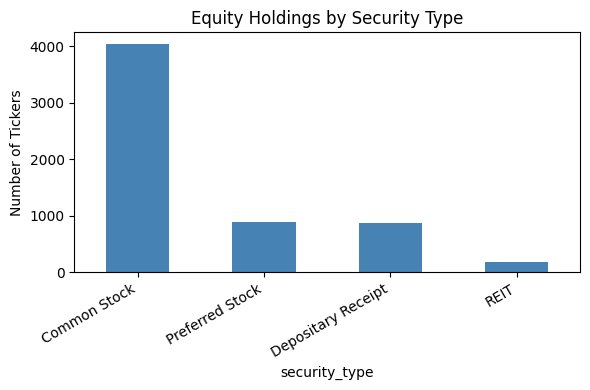

In [71]:
fig, ax = plt.subplots(figsize=(6, 4))
equity_only["security_type"].value_counts().plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Number of Tickers")
ax.set_title("Equity Holdings by Security Type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "charts", "equity_security_types.png"), dpi=100)
plt.show()

## Download Market Benchmark Data

Downloads S&P 500 index prices, used later to construct a market-adjusted excess return label (i.e. did a holding underperform the general market, rather than simply falling in absolute terms). The S&P 500 was chosen as a simple, standard, widely recognised benchmark; a more granular sector-specific benchmark was considered but treated as an optional refinement rather than a requirement, to keep the label construction defensible and scoped appropriately for this study.

In [30]:
# Download S&P 500 benchmark data
benchmark = yf.download("^GSPC", start="2015-01-01", end="2018-01-01", auto_adjust=True)
benchmark.to_csv(os.path.join(PROCESSED_DATA_DIR, "sp500_benchmark.csv"))
print(f"benchmark shape: {benchmark.shape}")

benchmark.head()

[*********************100%***********************]  1 of 1 completed

benchmark shape: (755, 5)


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2015-01-02,2058.199951,2072.360107,2046.040039,2058.899902,2708700000
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000


## Download Historical Prices for Mapped Tickers

Downloads historical daily price data for every successfully mapped ticker, in batches, with checkpointing so that an interrupted run can resume without re-downloading already-completed batches. A large number of individual ticker failures are expected and normal at this scale (e.g. delisted securities, or ticker-style identifiers that correspond to bonds rather than tradeable equities), and do not indicate a fault in the download process itself.

In [31]:
# Download historical prices for all mapped tickers, in checkpointed batches
def download_prices_in_batches(tickers, start="2015-01-01", end="2018-01-01", 
                                  batch_size=50, checkpoint_dir=None):
    os.makedirs(checkpoint_dir, exist_ok=True)
    total = len(tickers)
    failed_tickers = []

    for i in range(0, total, batch_size):
        batch = tickers[i:i + batch_size]
        batch_num = i // batch_size
        checkpoint_file = os.path.join(checkpoint_dir, f"batch_{batch_num}.csv")

        if os.path.exists(checkpoint_file):
            continue

        try:
            data = yf.download(batch, start=start, end=end, group_by='ticker', 
                                 auto_adjust=True, progress=False, threads=True)
            data.to_csv(checkpoint_file)
        except Exception:
            failed_tickers.extend(batch)

    return failed_tickers

unique_tickers = mapped_only["ticker"].unique().tolist()
failed = download_prices_in_batches(
    unique_tickers,
    checkpoint_dir=os.path.join(PROCESSED_DATA_DIR, "price_batches")
)
print(f"Failed batches: {len(failed)}")

$AGREX: Data doesn't exist for startDate = 1420088400, endDate = 1514782800
$ARGYX: Data doesn't exist for startDate = 1420088400, endDate = 1514782800
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AMAC 1999-RS1 B3"}}}
$AACH: possibly delisted; no timezone found
$AMAC 1999-RS1 B3: possibly delisted; no timezone found
Failed to get ticker 'AFL 5.5 09/15/52' reason: Expecting value: line 1 column 1 (char 0)
$AFL 5.5 09/15/52: possibly delisted; no timezone found
$AGNC 7.75 PERP B: possibly delisted; no timezone found
$AQBN: Data doesn't exist for startDate = 1420088400, endDate = 1514782800
$AQFD: Data doesn't exist for startDate = 1420088400, endDate = 1514782800
Failed to get ticker 'AES 7.375 07/01/21' reason: Expecting value: line 1 column 1 (char 0)
$AES 7.375 07/01/21: possibly delisted; no timezone found
Failed to get ticker 'AIR 2.25 03/01/16 B' reason: Expecting value: line 1 column 1 (char 0)
$AIR 2.25 03/0

Failed batches: 0


## Quantify Price Download Failures (Survivorship Bias Check)

Individual ticker failures during the price download are expected (delisted securities, bond-like tickers with no timezone data, etc.), but this exclusion is not necessarily random with respect to outcome. A security that was delisted, went bankrupt, or was acquired under financial distress is simultaneously more likely to fail a price download *and* more likely to represent exactly the severe-loss case this study's label is designed to detect. If left unaddressed, this could systematically bias the model toward underestimating concentration risk, since the most extreme negative outcomes may be disproportionately excluded before the label is even constructed. This is quantified here and must be stated explicitly as a limitation in Preprocessing.MD, not treated as routine missing data.

In [66]:
attempted_tickers = set(equity_only["ticker"].unique())
tickers_with_data = set()

for batch_file in glob.glob(os.path.join(PROCESSED_DATA_DIR, "price_batches", "batch_*.csv")):
    batch_df = pd.read_csv(batch_file, header=[0, 1], index_col=0)
    for ticker in batch_df.columns.get_level_values(0).unique():
        try:
            if ticker in attempted_tickers and batch_df[(ticker, "Close")].notna().any():
                tickers_with_data.add(ticker)
        except KeyError:
            pass

missing_price_data = attempted_tickers - tickers_with_data
print(f"Equity tickers attempted: {len(attempted_tickers)}")
print(f"Equity tickers with no usable price data: {len(missing_price_data)}")
print(f"Failure rate: {len(missing_price_data)/len(attempted_tickers):.1%}")

Equity tickers attempted: 5997
Equity tickers with no usable price data: 2546
Failure rate: 42.5%


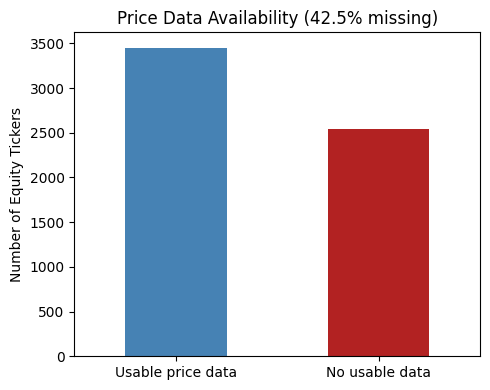

In [72]:
fig, ax = plt.subplots(figsize=(5, 4))
pd.Series({"Usable price data": len(attempted_tickers) - len(missing_price_data), "No usable data": len(missing_price_data)}).plot(
    kind="bar", ax=ax, color=["steelblue", "firebrick"]
)
ax.set_ylabel("Number of Equity Tickers")
ax.set_title(f"Price Data Availability ({len(missing_price_data)/len(attempted_tickers):.1%} missing)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "charts", "price_data_survivorship.png"), dpi=100)
plt.show()

## Consolidate Price Data

Combines all individually-downloaded price batches into a single table, extracting only the closing price for each ticker, since that is what is needed for both valuing holdings and computing returns.

In [32]:
# Consolidate all price batch files into one Close-price table
batch_files = glob.glob(os.path.join(PROCESSED_DATA_DIR, "price_batches", "batch_*.csv"))
all_close_prices = {}

for batch_file in batch_files:
    batch_df = pd.read_csv(batch_file, header=[0, 1], index_col=0)
    for ticker in batch_df.columns.get_level_values(0).unique():
        try:
            all_close_prices[ticker] = batch_df[(ticker, "Close")]
        except KeyError:
            pass

close_prices_df = pd.DataFrame(all_close_prices)
close_prices_df.index = pd.to_datetime(close_prices_df.index)
close_prices_df.to_csv(os.path.join(PROCESSED_DATA_DIR, "all_close_prices.csv"))
print(f'close_prices_df shape : {close_prices_df.shape}')

close_prices_df.head()

close_prices_df shape : (755, 13746)


,AERN,AAON,AGREX,ACCO,ARGYX,ACTDX,AACH,AGCO,AMAC 1999-RS1 B3,GGHCX,...,FSP,USPX,BEN,UDIV,FRNJX,FBDIX,FLQL,FNCZX,FHYVX,FFACX
2015-01-02,0.00001,13.568209,NaN,5.758767,NaN,5.609174,NaN,35.518490,NaN,20.405333,...,6.813981,NaN,32.925896,NaN,8.261082,80.251648,NaN,8.586912,6.420429,9.694896
2015-01-05,0.00001,13.110370,NaN,5.647392,NaN,5.620360,NaN,33.885376,NaN,20.262939,...,6.906729,NaN,31.834091,NaN,8.274852,80.303497,NaN,8.593963,6.432441,9.524420
2015-01-06,0.00001,12.900007,NaN,5.503256,NaN,5.648319,NaN,33.727577,NaN,20.158514,...,6.879448,NaN,31.211061,NaN,8.302388,78.974373,NaN,8.615131,6.462471,9.457711
2015-01-07,0.00001,13.017560,NaN,5.457397,NaN,5.653908,NaN,33.703911,NaN,20.580956,...,6.939459,NaN,31.620489,NaN,8.302388,81.415817,NaN,8.615131,6.462471,9.531832
2015-01-08,0.00001,13.339290,NaN,5.693253,NaN,5.648319,NaN,34.421860,NaN,20.879986,...,6.923092,NaN,32.035843,NaN,8.295502,82.231194,NaN,8.608074,6.456460,9.672660


## Final Output: Equity-Only Price Table

Filters the consolidated price table down to only the tickers identified as genuine equity holdings in an earlier step. This is the final preprocessing output, saved as `equity_close_prices.csv`, and is the file that feature engineering will build on.

In [68]:
# Filter consolidated prices to equity-only tickers (final preprocessing output)
equity_tickers_list = equity_only["ticker"].unique().tolist()
available_equity_tickers = [t for t in equity_tickers_list if t in close_prices_df.columns]

equity_close_prices = close_prices_df[available_equity_tickers]
equity_close_prices.to_csv(os.path.join(PROCESSED_DATA_DIR, "equity_close_prices.csv"))

print(f"Equity tickers with price data: {len(available_equity_tickers)} / {len(equity_tickers_list)}")
print(f" equity_close_prices.shape: {equity_close_prices.shape}")

equity_close_prices.head()

NameError: name 'close_prices_df' is not defined

## Remove Tickers With No Usable Price Data

The consolidated price table (`equity_close_prices.csv`) still contains a column for every ticker that was *requested*, including those that completely failed to download (`yfinance` fills these with `NaN` rather than omitting the column). Per the survivorship bias limitation documented above (42.5% of mapped equity tickers), these tickers are removed here, producing the genuinely final preprocessing output, `equity_close_prices_clean.csv`, which contains only tickers with at least some real, usable price data.

In [7]:
# Remove tickers with no usable price data at all
# (yfinance creates a column even for tickers that completely failed to download,
# filled entirely with NaN - these must be removed here, not left for Feature Engineering,
# since this notebook's own Preprocessing.MD documents this exact limitation as resolved)

usable_columns = equity_close_prices.columns[~equity_close_prices.isna().all()]
equity_close_prices_clean = equity_close_prices[usable_columns].copy()

print(f"Equity tickers before removing all-null columns: {len(equity_close_prices.columns)}")
print(f"Equity tickers with at least some usable price data: {len(equity_close_prices_clean.columns)}")

equity_close_prices_clean.to_csv(os.path.join(PROCESSED_DATA_DIR, "equity_close_prices_clean.csv"))
print("\nFinal preprocessing output saved as equity_close_prices_clean.csv")

Equity tickers before removing all-null columns: 5995
Equity tickers with at least some usable price data: 3451

Final preprocessing output saved as equity_close_prices_clean.csv
